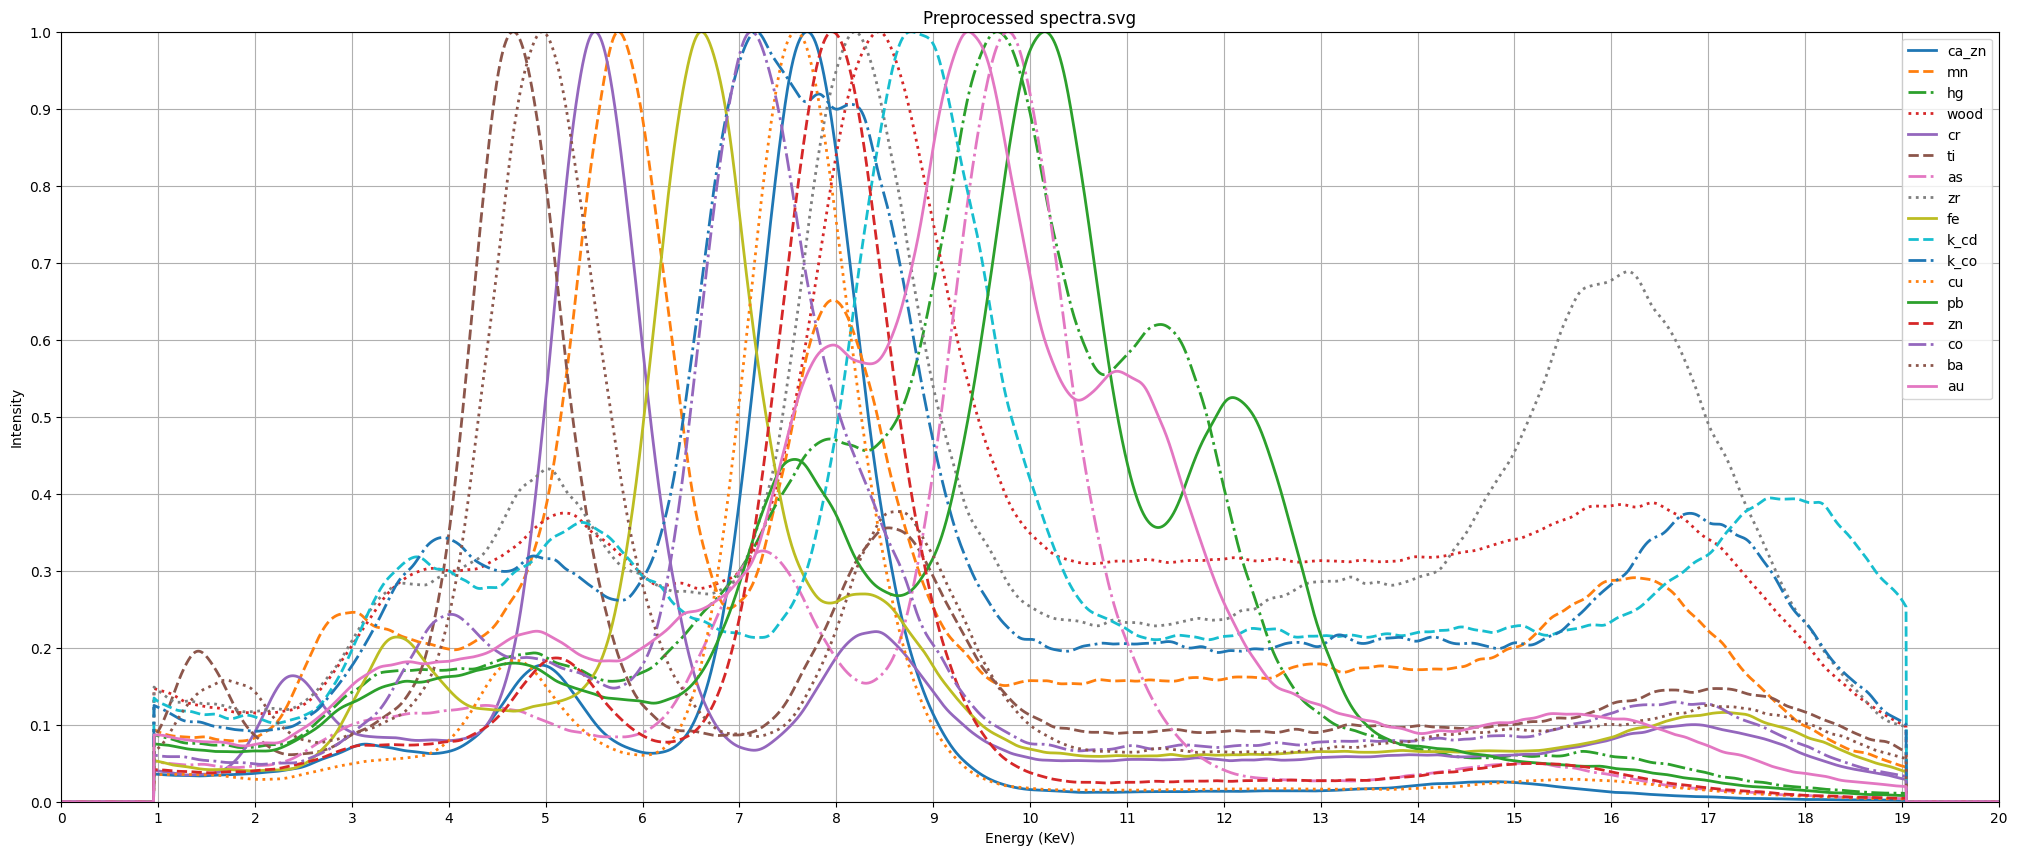

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import itertools

spectra = np.load("data/objects/pigment_palette/0_preprocessed_spectra.npz",allow_pickle=True)

line_styles = ['-', '--', '-.', ':']
plt.figure(figsize=(25, 10))
for (pad_name, spectrum), linestyle in zip(
    spectra.items(), itertools.cycle(line_styles)
):
    plt.plot(np.linspace(0, 20, 4096), spectrum, linestyle=linestyle, label=pad_name, linewidth=2)
    plt.set_cmap("tab10")


plt.legend()
plt.ylim(0, 1)
plt.xlim(0, 20)
plt.grid(True)
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel("Energy (KeV)")
plt.ylabel("Intensity")
plt.title("Preprocessed spectra.svg")
plt.savefig("data/plots/preprocessed_spectra.svg", dpi=300, bbox_inches='tight',  pad_inches=0)

/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:207: RuntimeWarning: Performing pixel-wise extrapolation, which can be slow for large images.
  warnings.warn("Performing pixel-wise extrapolation, which can be slow for large images.", RuntimeWarning)


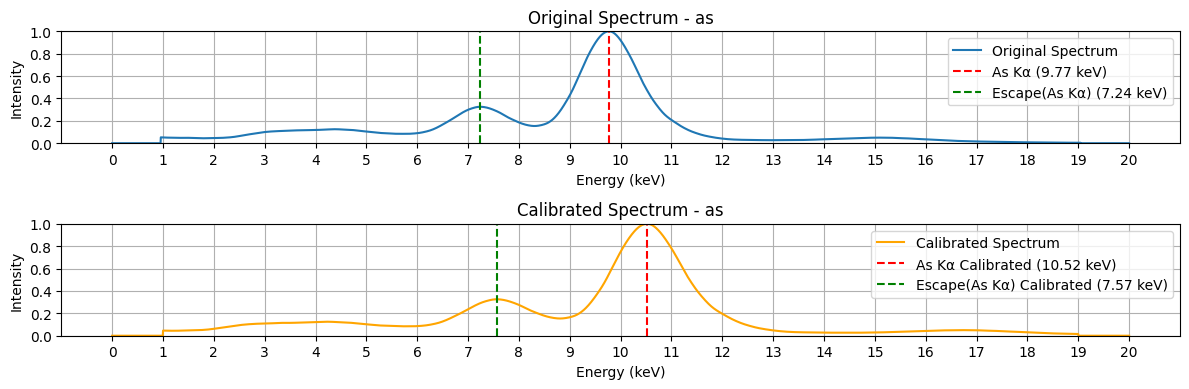

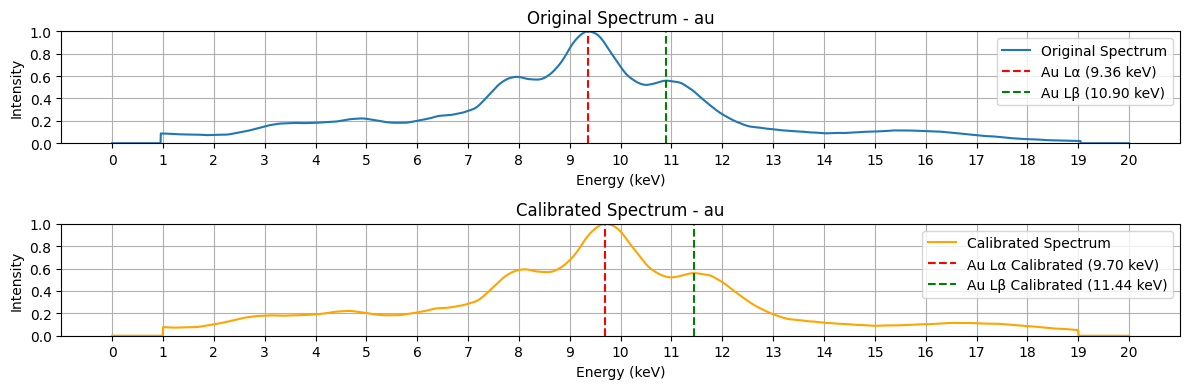

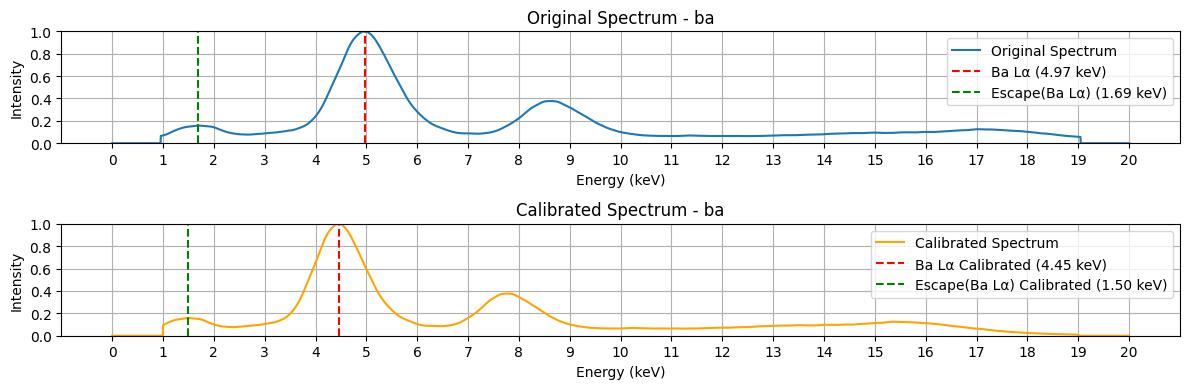

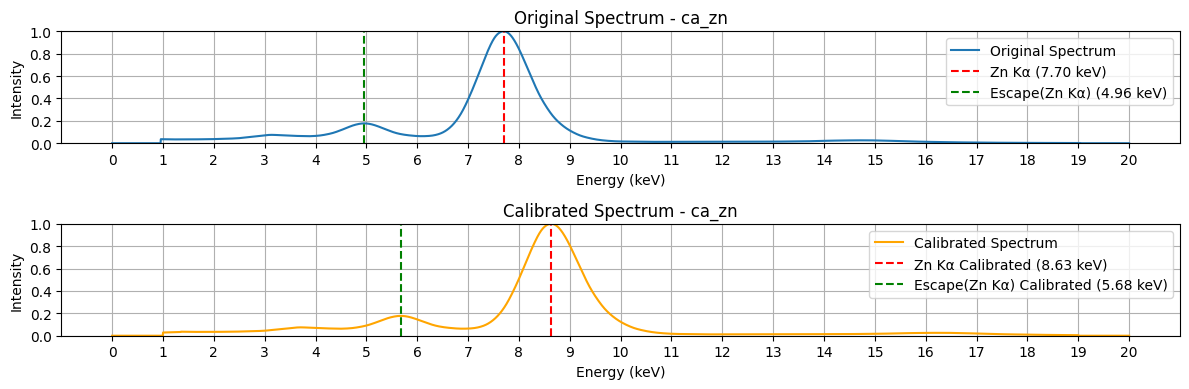

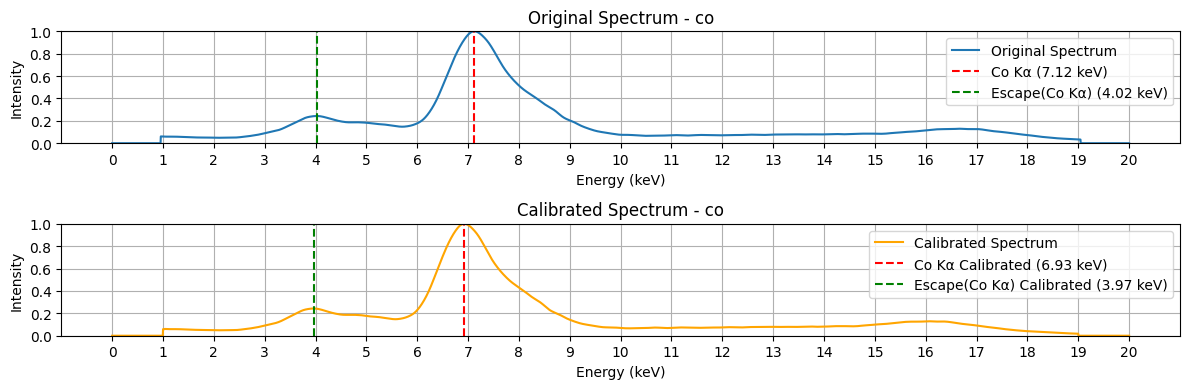

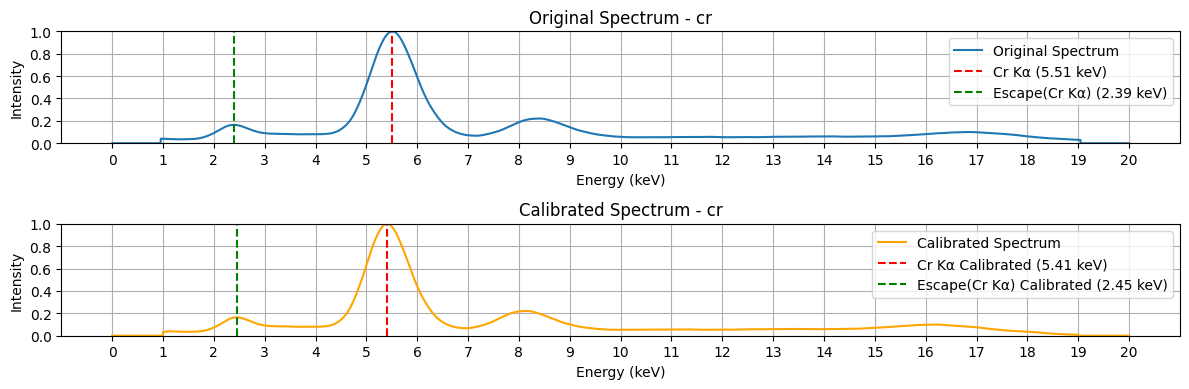

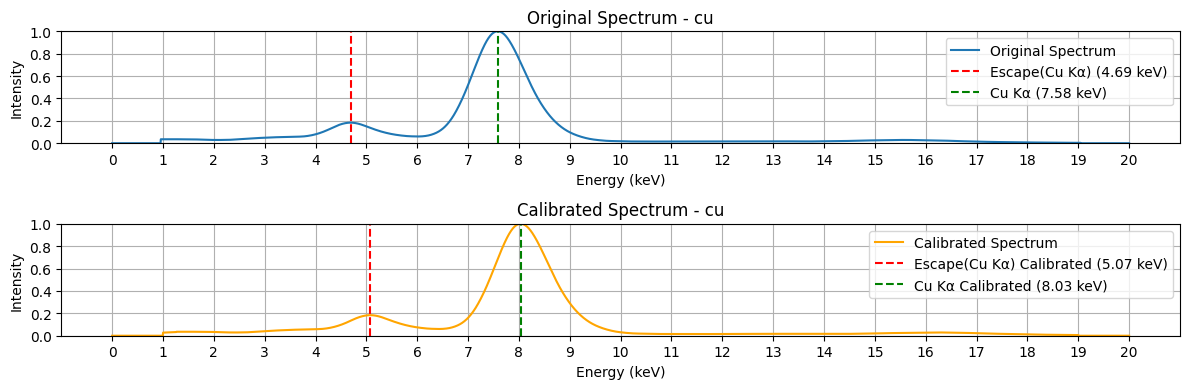

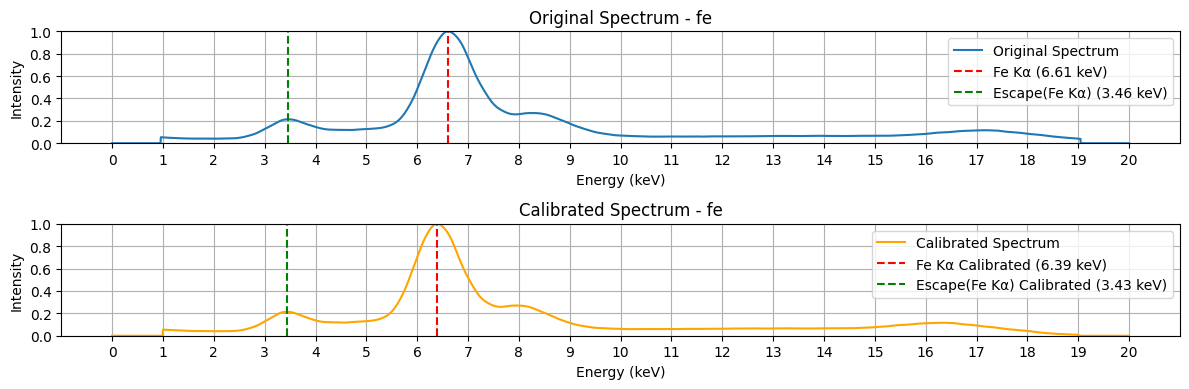

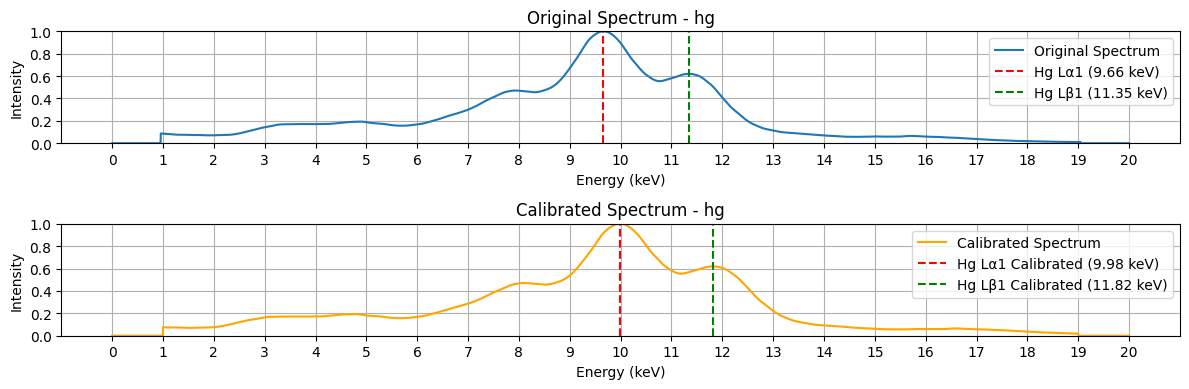

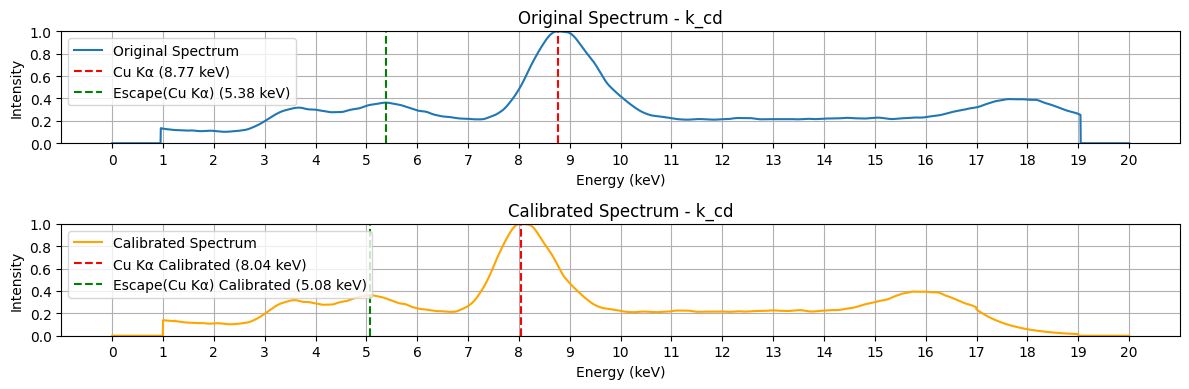

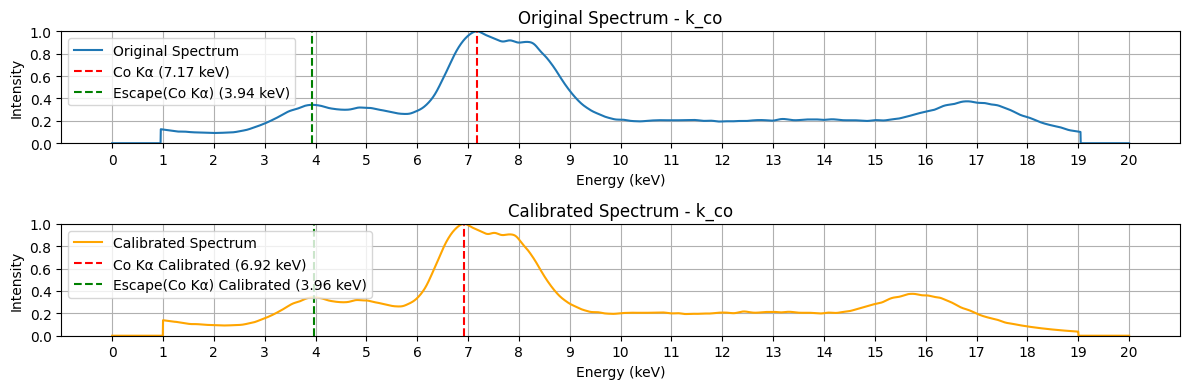

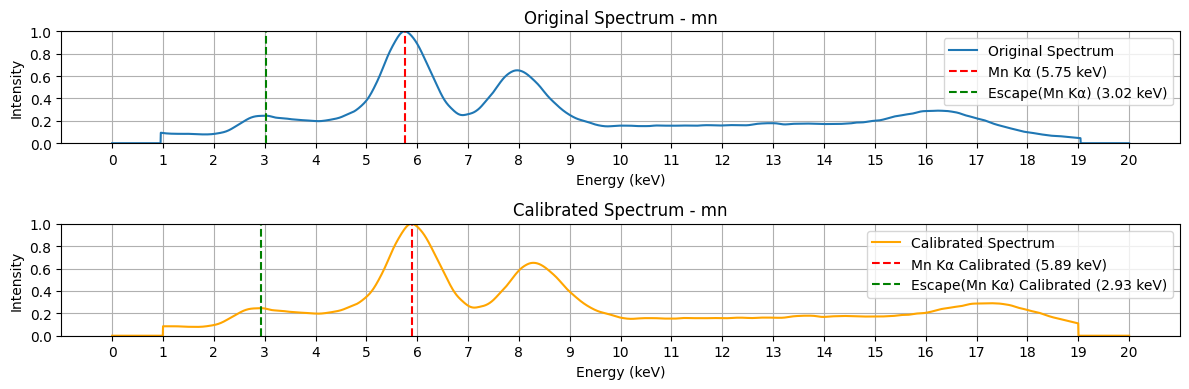

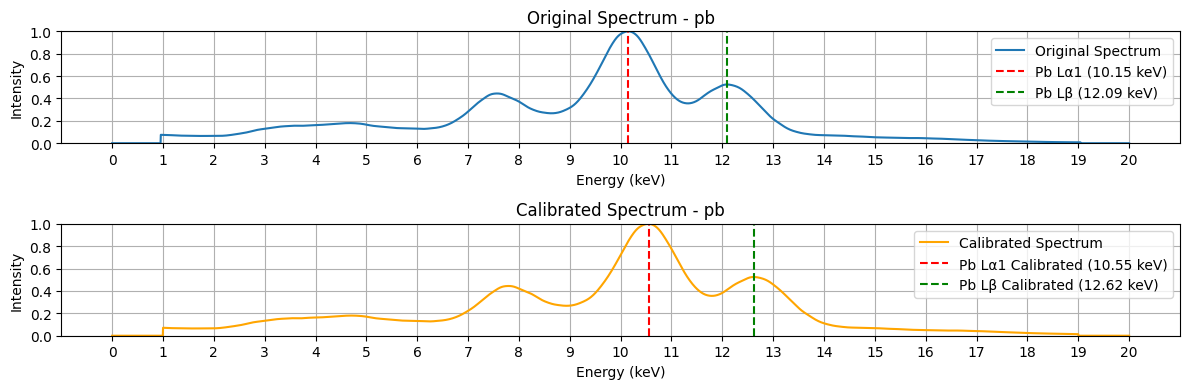

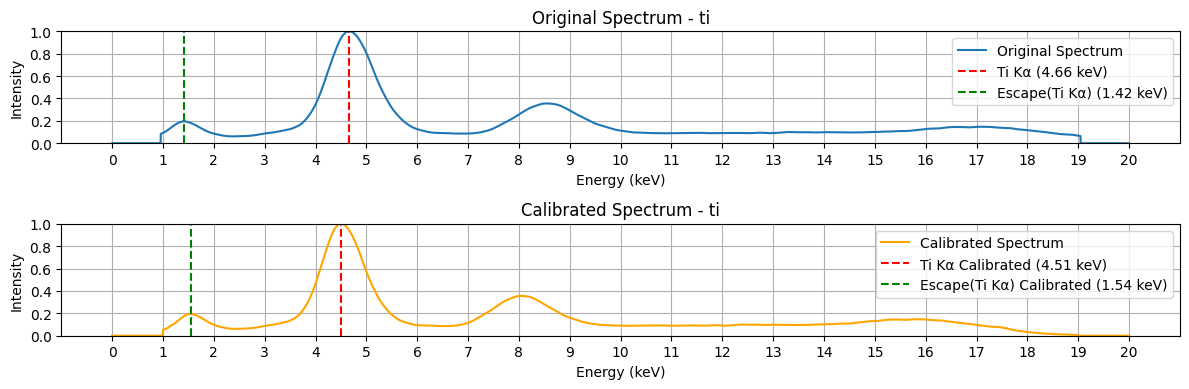

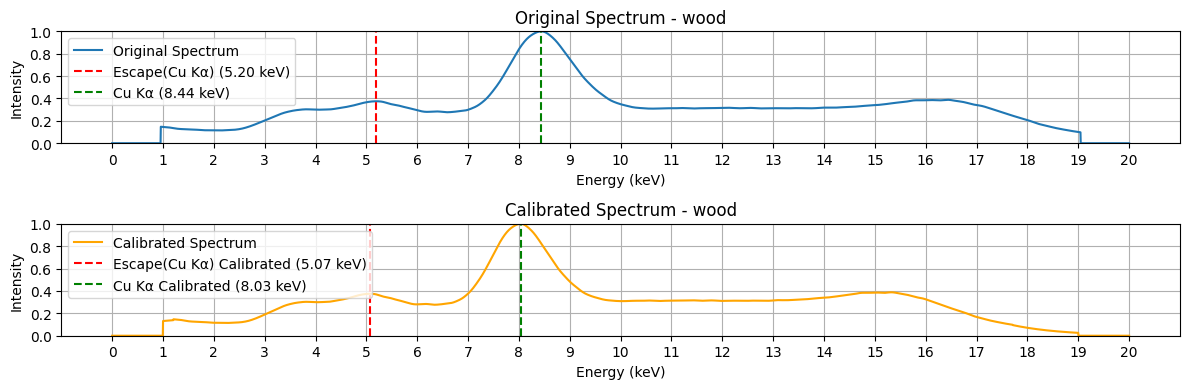

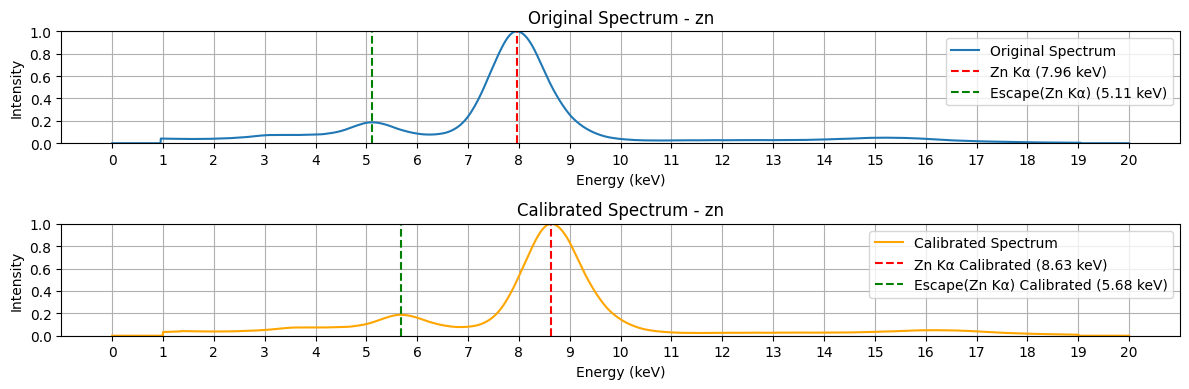

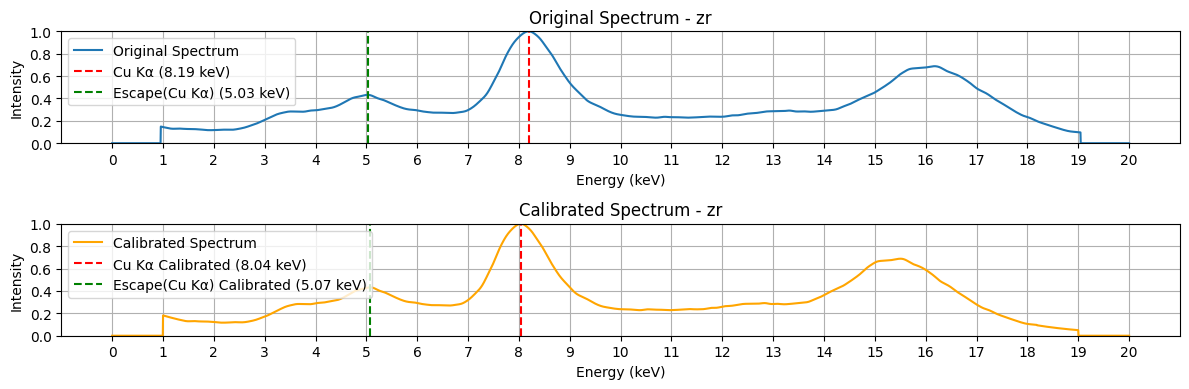

In [2]:
from src.DataPreprocessor import DataPreprocessor
from src.Elements import Elements

# Define peak finder functions for different materials
def cu_wood_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    escape_peak = np.argmax(spectrum[:max(0, main_peak - 400)])
    return [escape_peak, main_peak]

def hg_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[main_peak + 300:]) + main_peak + 300
    return [main_peak, second_peak]

def ca_zn_pb_peak_finder(spectrum):
    main_peak = np.argmax(spectrum[2000:]) + 2000
    second_peak = np.argmax(spectrum[main_peak + 300:]) + main_peak + 300
    return [main_peak, second_peak]

def pb_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[main_peak + 300:]) + main_peak + 300
    return [main_peak, second_peak]

def ca_zn_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def as_ca_zn_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def mn_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def cr_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def ti_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def as_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300]) 
    return [main_peak, second_peak]

def zr_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def fe_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def k_cd_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def k_co_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def zn_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def co_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def ba_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[:main_peak - 300])
    return [main_peak, second_peak]

def au_peak_finder(spectrum):
    main_peak = np.argmax(spectrum)
    second_peak = np.argmax(spectrum[main_peak + 300:]) + main_peak + 300
    return [main_peak, second_peak]

# Configuration for each material defining how to process and plot
pad_configs = {
    "cu": {
        "peak_finder": cu_wood_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cu",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cu Kα)"
            },
            {
                "element": "cu",
                "line": "k_alpha",
                "label": "Cu Kα"
            }
        ]
    },
    "wood": {
        "peak_finder": cu_wood_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cu",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cu Kα)"
            },
            {
                "element": "cu",
                "line": "k_alpha",
                "label": "Cu Kα"
            }
        ]
    },
    "hg": {
        "peak_finder": hg_peak_finder,
        "peaks_energy_info": [
            {
                "element": "hg",
                "line": "l_alpha1",
                "label": "Hg Lα1"
            },
            {
                "element": "hg",
                "line": "l_beta1",
                "label": "Hg Lβ1"
            }
        ]
    },
    "ca_zn_pb": {
        "peak_finder": ca_zn_pb_peak_finder,
        "peaks_energy_info": [
            {
                "element": "pb",
                "line": "l_alpha1",
                "label": "Pb Lα1"
            },
            {
                "element": "pb",
                "line": "l_beta",
                "label": "Pb Lβ"
            }
        ]
    },
    "pb": {
        "peak_finder": pb_peak_finder,
        "peaks_energy_info": [
            {
                "element": "pb",
                "line": "l_alpha1",
                "label": "Pb Lα1"
            },
            {
                "element": "pb",
                "line": "l_beta",
                "label": "Pb Lβ"
            }
        ]
    },
    "ca_zn": {
        "peak_finder": ca_zn_peak_finder,
        "peaks_energy_info": [
            {
                "element": "zn",
                "line": "k_alpha",
                "label": "Zn Kα"
            },
            {
                "element": "zn",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Zn Kα)"
            },
        ]
    },
    "as_ca_zn": {
        "peak_finder": as_ca_zn_peak_finder,
        "peaks_energy_info": [
            {
                "element": "as",
                "line": "k_alpha",
                "label": "As Kα"
            },
            {
                "element": "as",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(As Kα)"
            }
        ]
    },
    "mn": {
        "peak_finder": mn_peak_finder,
        "peaks_energy_info": [
            {
                "element": "mn",
                "line": "k_alpha",
                "label": "Mn Kα"
            },
            {
                "element": "mn",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Mn Kα)"
            }
        ]
    },
    "cr": {
        "peak_finder": cr_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cr",
                "line": "k_alpha",
                "label": "Cr Kα"
            },
            {
                "element": "cr",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cr Kα)"
            }
        ]
    },
    "ti": {
        "peak_finder": ti_peak_finder,
        "peaks_energy_info": [
            {
                "element": "ti",
                "line": "k_alpha",
                "label": "Ti Kα"
            },
            {
                "element": "ti",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Ti Kα)"
            }
        ]
    },
    "as": {
        "peak_finder": as_peak_finder,
        "peaks_energy_info": [
            {
                "element": "as",
                "line": "k_alpha",
                "label": "As Kα"
            },
            {
                "element": "as",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(As Kα)"
            }
        ]
    },
    "zr": {
        "peak_finder": zr_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cu",
                "line": "k_alpha",
                "label": "Cu Kα"
            },
            {
                "element": "cu",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cu Kα)"
            }
        ]
    },
    "fe": {
        "peak_finder": fe_peak_finder,
        "peaks_energy_info": [
            {
                "element": "fe",
                "line": "k_alpha",
                "label": "Fe Kα"
            },
            {
                "element": "fe",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Fe Kα)"
            }
        ]
    },
    "k_cd": {
        "peak_finder": k_cd_peak_finder,
        "peaks_energy_info": [
            {
                "element": "cu",
                "line": "k_alpha",
                "label": "Cu Kα"
            },
            {
                "element": "cu",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Cu Kα)"
            }
        ]
    },
    "k_co": {
        "peak_finder": k_co_peak_finder,
        "peaks_energy_info": [
            {
                "element": "co",
                "line": "k_alpha",
                "label": "Co Kα"
            },
            {
                "element": "co",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Co Kα)"
            }
        ]
    },
    "zn": {
        "peak_finder": zn_peak_finder,
        "peaks_energy_info": [
            {
                "element": "zn",
                "line": "k_alpha",
                "label": "Zn Kα"
            },
            {
                "element": "zn",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Zn Kα)"
            }
        ]
    },
    "co": {
        "peak_finder": co_peak_finder,
        "peaks_energy_info": [
            {
                "element": "co",
                "line": "k_alpha",
                "label": "Co Kα"
            },
            {
                "element": "co",
                "line": "k_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Co Kα)"
            }
        ]
    },
    "ba": {
        "peak_finder": ba_peak_finder,
        "peaks_energy_info": [
            {
                "element": "ba",
                "line": "l_alpha",
                "label": "Ba Lα"
            },
            {
                "element": "ba",
                "line": "l_alpha",
                "energy_offset": -Elements.ESCAPE_ENERGY_DIFF,
                "label": "Escape(Ba Lα)"
            }
        ]
    },
    "au": {
        "peak_finder": au_peak_finder,
        "peaks_energy_info": [
            {
                "element": "au",
                "line": "l_alpha",
                "label": "Au Lα"
            },
            {
                "element": "au",
                "line": "l_beta",
                "label": "Au Lβ"
            }
        ]
    }
}

calibrated_spectra = {}

def calibrate_and_plot_spectrum(pad_name, spectrum):
    config = pad_configs.get(pad_name)
    if not config:
        return None  # Skip unknown materials
    
    peak_finder = config["peak_finder"]
    peaks_energy_info = config["peaks_energy_info"]
    
    # Detect peaks in original spectrum
    original_peaks = peak_finder(spectrum)
    
    # Calculate theoretical energies for each peak
    energies = []
    original_labels = []
    for peak_info in peaks_energy_info:
        element = peak_info["element"]
        line = peak_info["line"]
        energy = Elements.get_element_line_energy(element, line)
        if "energy_offset" in peak_info:
            energy += peak_info["energy_offset"]
        energies.append(energy)
        original_labels.append(peak_info["label"])
    
    # Process the spectrum
    energy_axis, processed_spectrum = DataPreprocessor.processed_spectrum(spectrum, original_peaks, energies)
    calibrated_spectra[f"{pad_name}_peaks"] = np.array(original_peaks)
    calibrated_spectra[f"{pad_name}_energies"] = np.array(energies)
    
    # Detect peaks in Calibrated spectrum
    Calibrated_peaks = peak_finder(processed_spectrum)
    Calibrated_labels = [f"{label} Calibrated" for label in original_labels]
    
    # Create plots
    fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=False)
    colors = ['r', 'g', 'm', 'c']
    
    # Plot original spectrum
    axs[0].plot(energy_axis, spectrum, label="Original Spectrum")
    for i, (pos, label) in enumerate(zip(original_peaks, original_labels)):
        axs[0].axvline(energy_axis[pos], color=colors[i], linestyle='--', 
                        label=f"{label} ({energy_axis[pos]:.2f} keV)")
    axs[0].set_title(f"Original Spectrum - {pad_name}")
    axs[0].legend()
    axs[0].set_xticks(np.arange(0, 21))
    axs[0].set_yticks(np.arange(0, 1.1, 0.2))
    axs[0].grid(True)
    axs[0].set_ylim(0, 1)  # Adjust based on normalization
    axs[0].set_xlabel("Energy (keV)")
    axs[0].set_ylabel("Intensity")
    
    # Plot Calibrated spectrum
    axs[1].plot(energy_axis, processed_spectrum, color='orange', label="Calibrated Spectrum")
    for i, (pos, label) in enumerate(zip(Calibrated_peaks, Calibrated_labels)):
        axs[1].axvline(energy_axis[pos], color=colors[i], linestyle='--', 
                        label=f"{label} ({energy_axis[pos]:.2f} keV)")
    axs[1].set_title(f"Calibrated Spectrum - {pad_name}")
    axs[1].legend()
    axs[1].set_xticks(np.arange(0, 21))
    axs[1].set_yticks(np.arange(0, 1.1, 0.2))
    axs[1].grid(True)
    axs[1].set_ylim(0, 1)  # Adjust based on normalization
    axs[1].set_xlabel("Energy (keV)")
    axs[1].set_ylabel("Intensity")
    
    plt.xlabel("Energy (keV)")
    plt.tight_layout()
    plt.savefig(f"data/plots/spectra_calibrated/{pad_name}.svg", dpi=300, bbox_inches='tight',  pad_inches=0)
    plt.show()

    return processed_spectrum


# Iterate over spectra dictionary
for pad_name, spectrum in sorted(spectra.items()):
    calibrated_spectrum = calibrate_and_plot_spectrum(pad_name, spectrum)
    if calibrated_spectrum is not None:
        calibrated_spectra[pad_name] = calibrated_spectrum

np.savez("data/objects/pigment_palette/1_calibrated_spectra.npz", **calibrated_spectra)

17
17


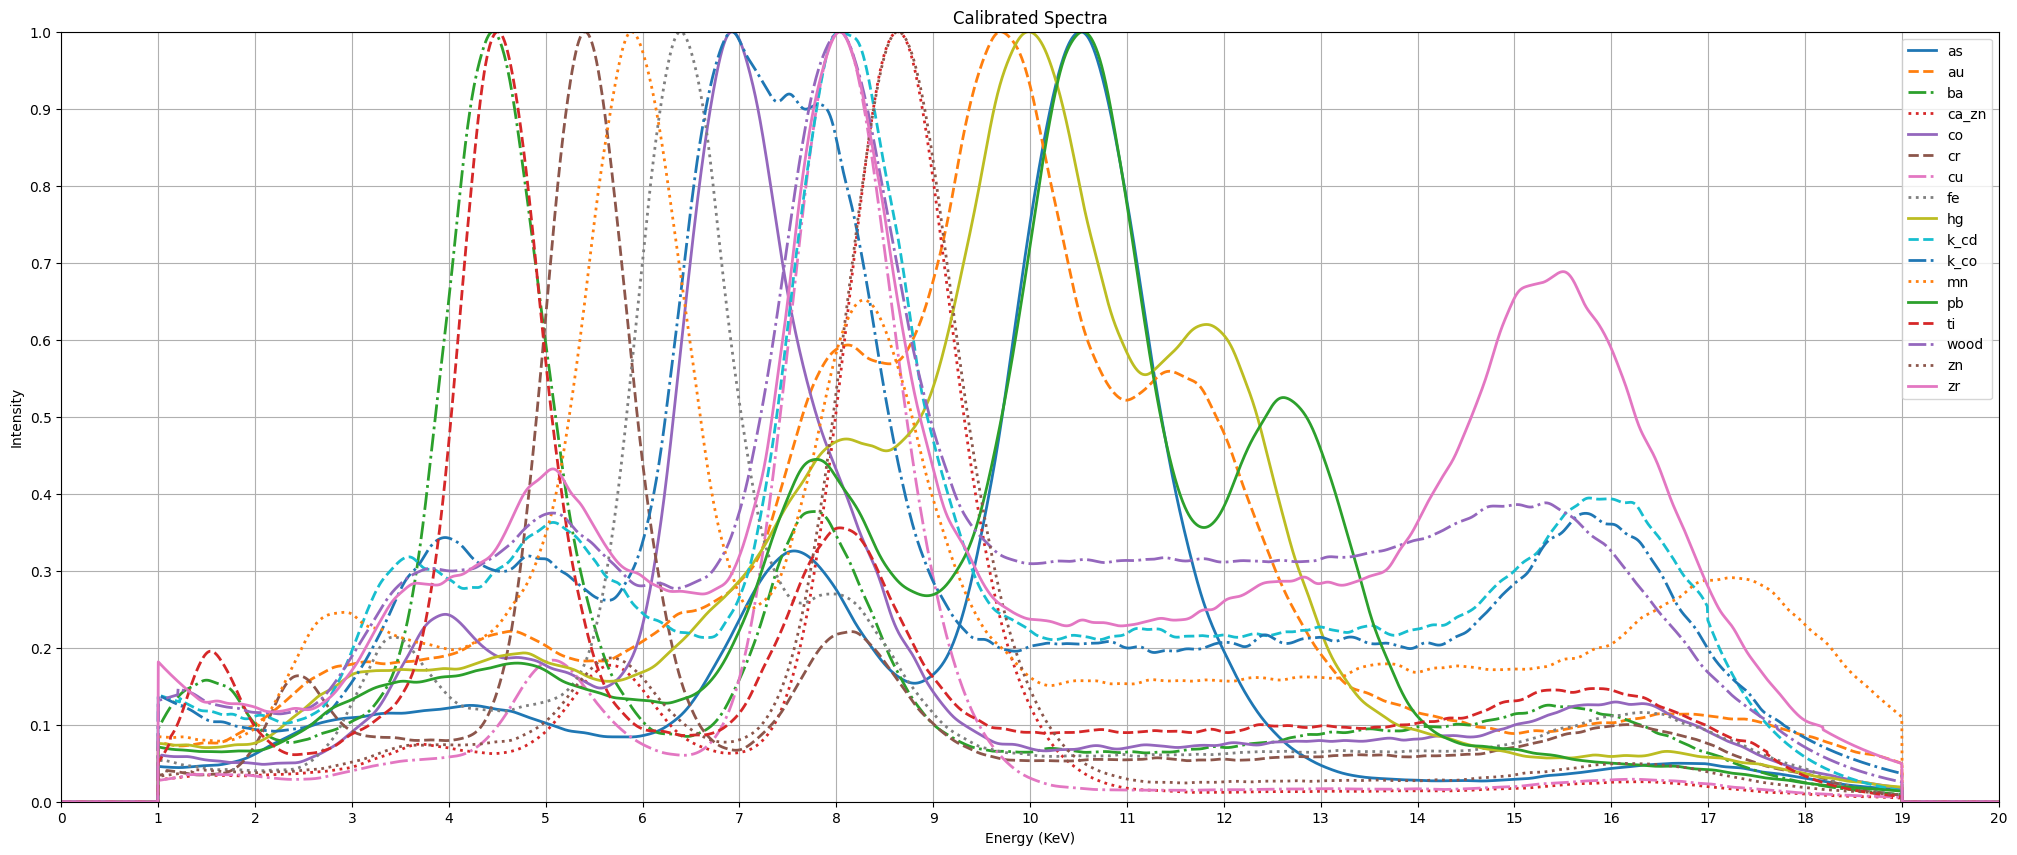

In [10]:
line_styles = ['-', '--', '-.', ':']
plt.figure(figsize=(25, 10))
print(len(calibrated_spectra))
print(len(spectra))
for (pad_name, spectrum), linestyle in zip(
    calibrated_spectra.items(), itertools.cycle(line_styles)
):

    plt.plot(np.linspace(0, 20, 4096),spectrum, linestyle=linestyle, label=pad_name, linewidth=2)
    plt.set_cmap("tab10")

plt.legend()
plt.ylim(0, 1)
plt.xlim(0, 20)
plt.grid(True)
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel("Energy (KeV)")
plt.ylabel("Intensity")
plt.title("Calibrated Spectra")
plt.savefig("data/plots/calibrated_spectra.svg", dpi=300, bbox_inches='tight',  pad_inches=0)
plt.show()

Processing: as
  -> Selected result from target_fraction ≈ 0.11


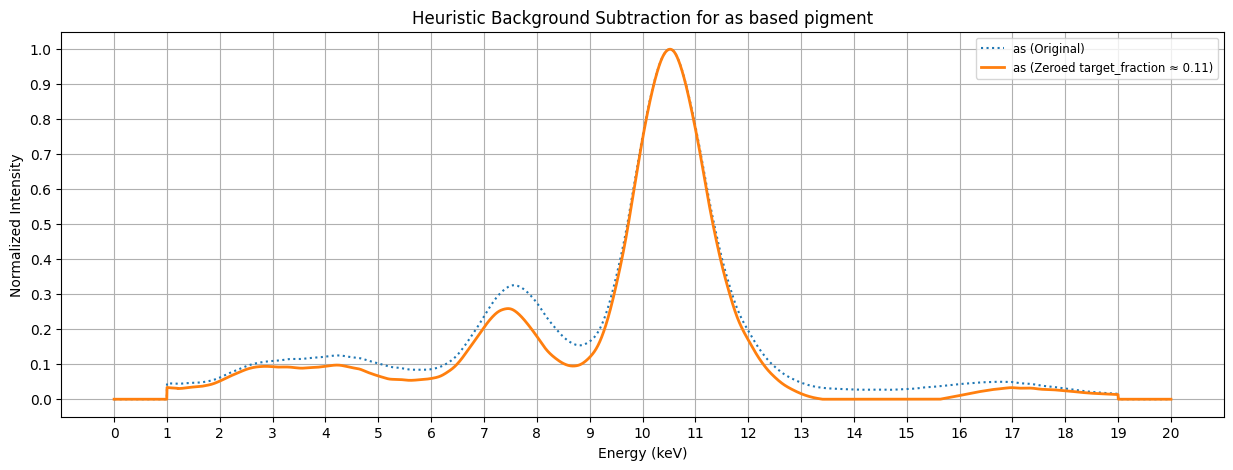

Processing: au
  -> Selected result from target_fraction ≈ 0.11


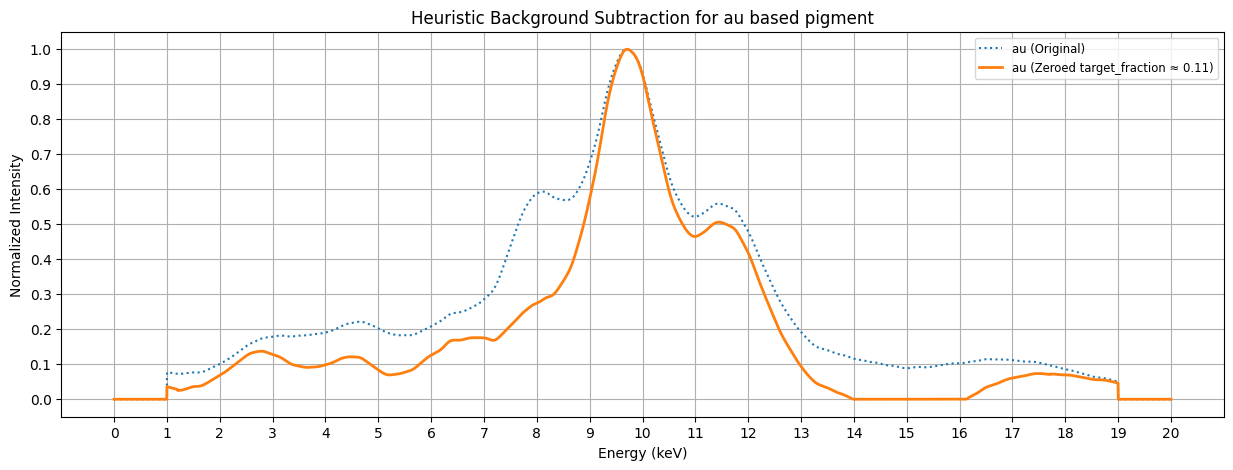

Processing: ba
  -> Selected result from target_fraction ≈ 0.11


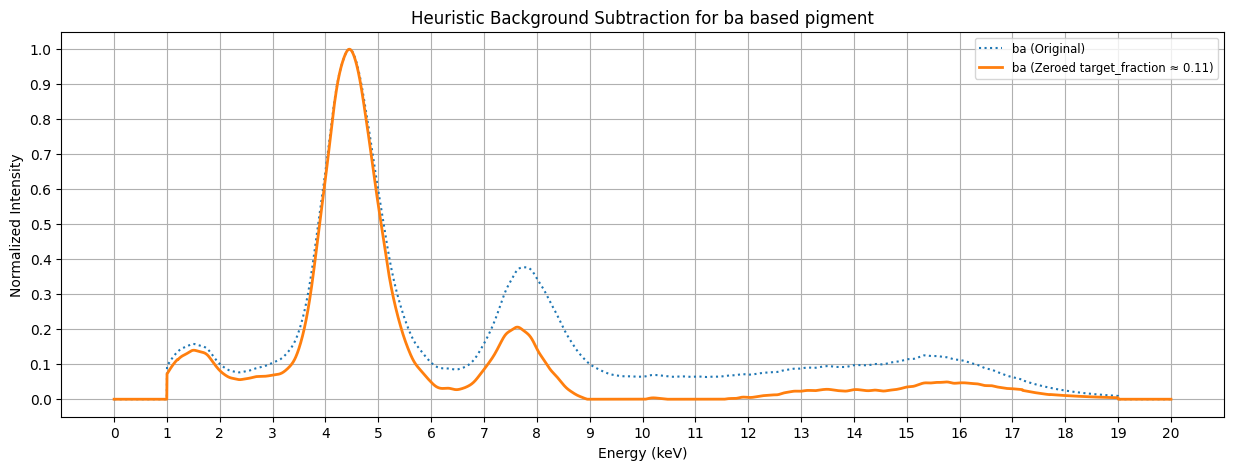

Processing: ca_zn
  -> Selected result from target_fraction ≈ 0.11


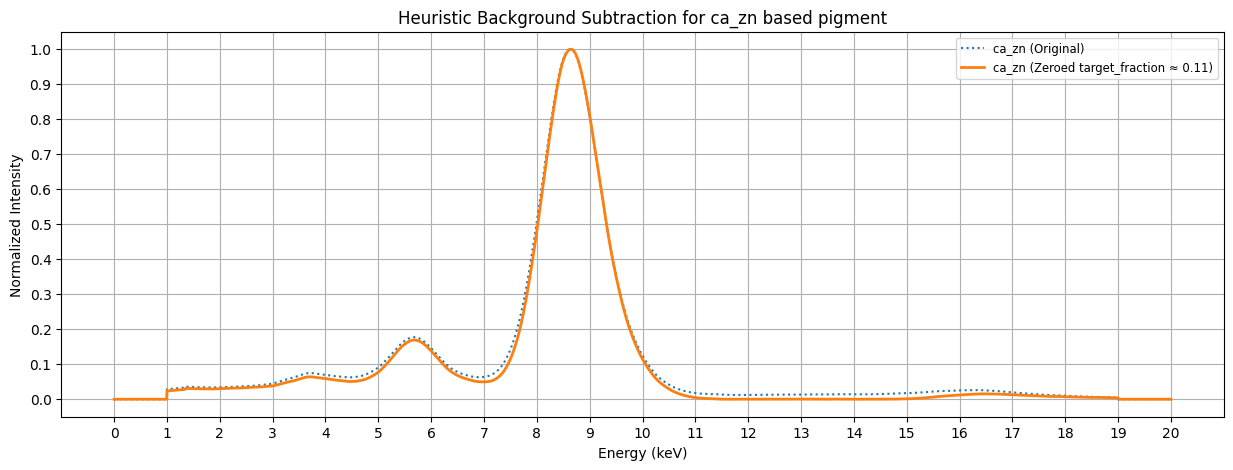

Processing: co
  -> Selected result from target_fraction ≈ 0.11


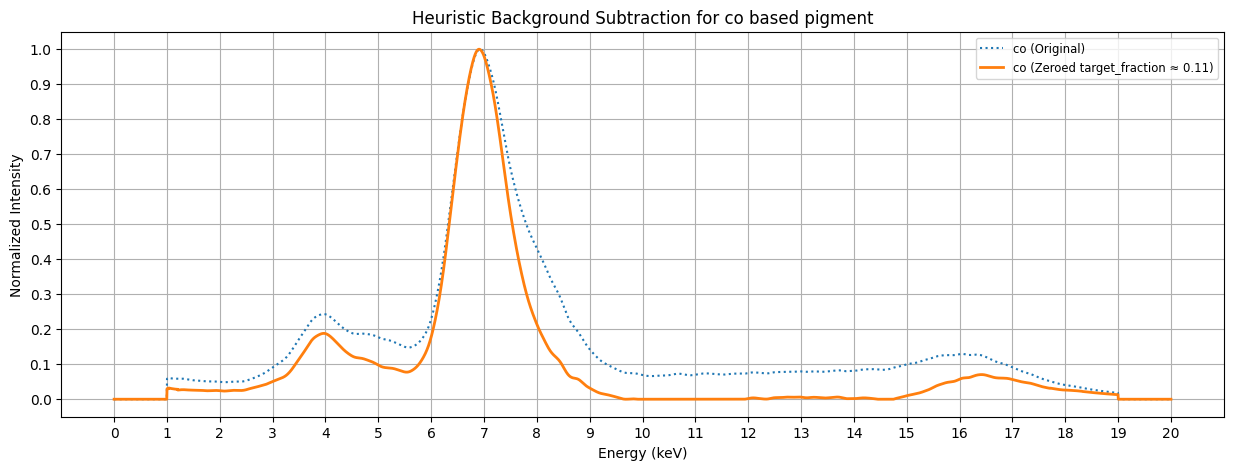

Processing: cr
  -> Selected result from target_fraction ≈ 0.11


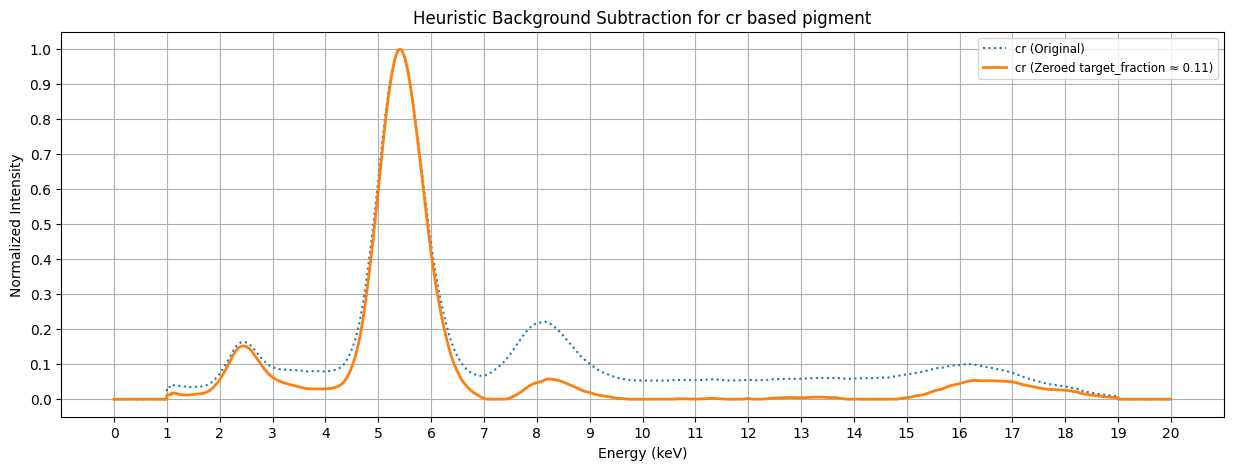

Processing: cu
  -> Selected result from target_fraction ≈ 0.11


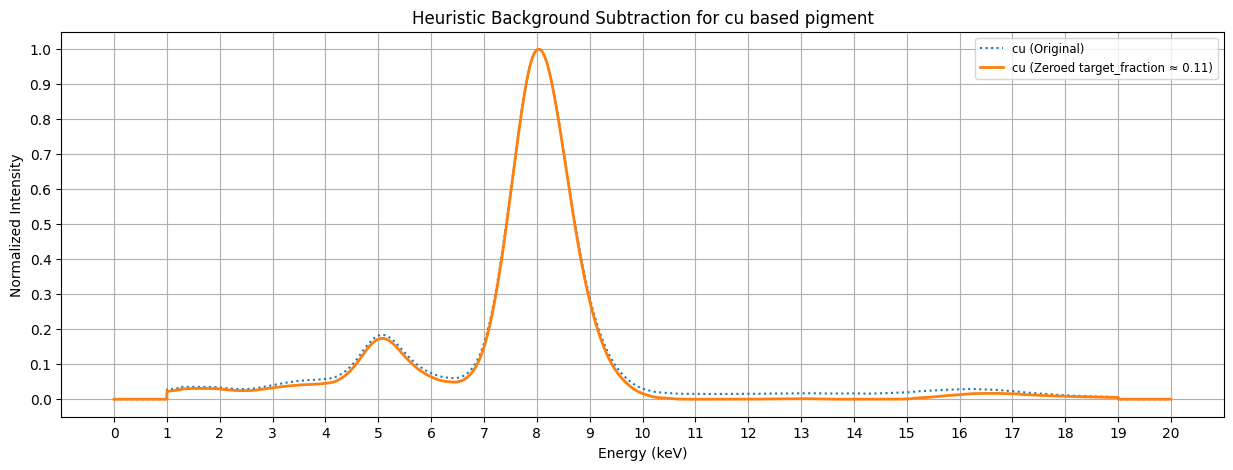

Processing: fe
  -> Selected result from target_fraction ≈ 0.11


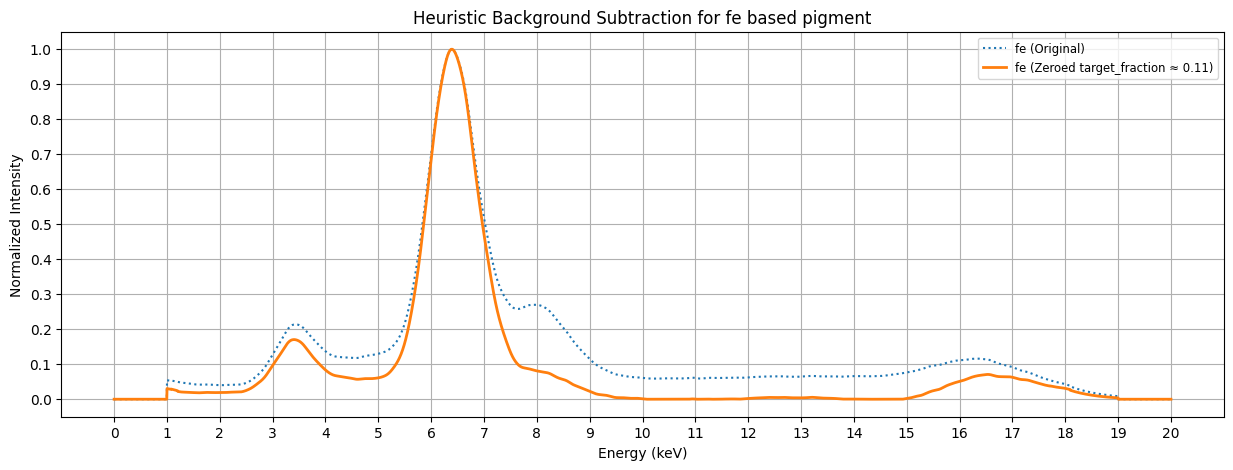

Processing: hg
  -> Selected result from target_fraction ≈ 0.11


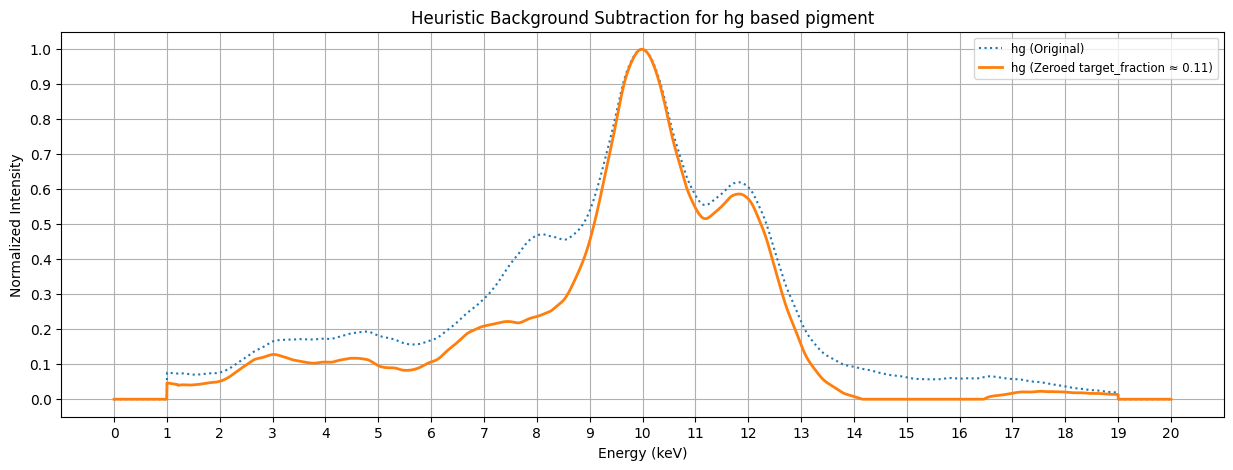

Processing: k_cd
  -> Selected result from target_fraction ≈ 0.11


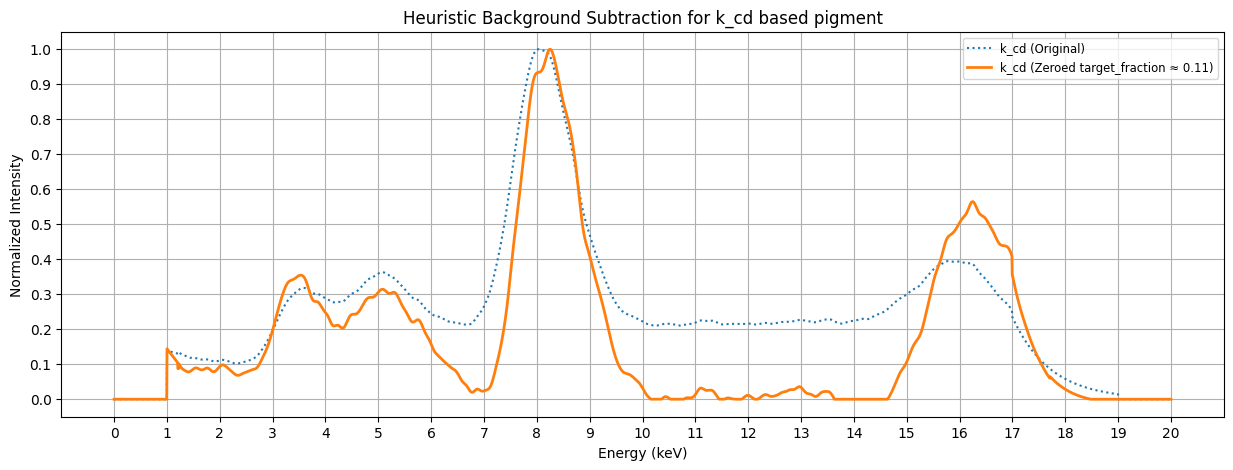

Processing: k_co
  -> Selected result from target_fraction ≈ 0.11


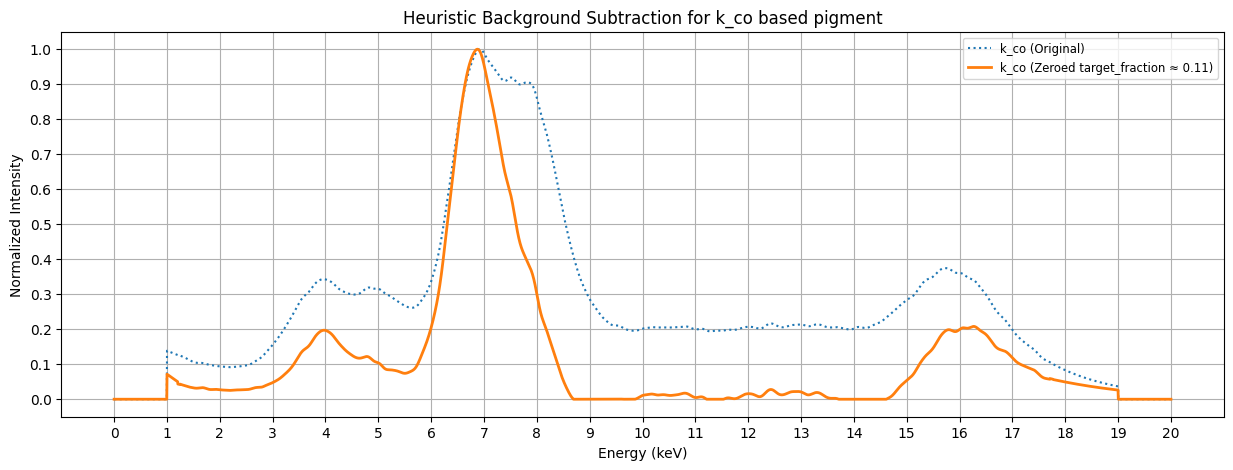

Processing: mn
  -> Selected result from target_fraction ≈ 0.11


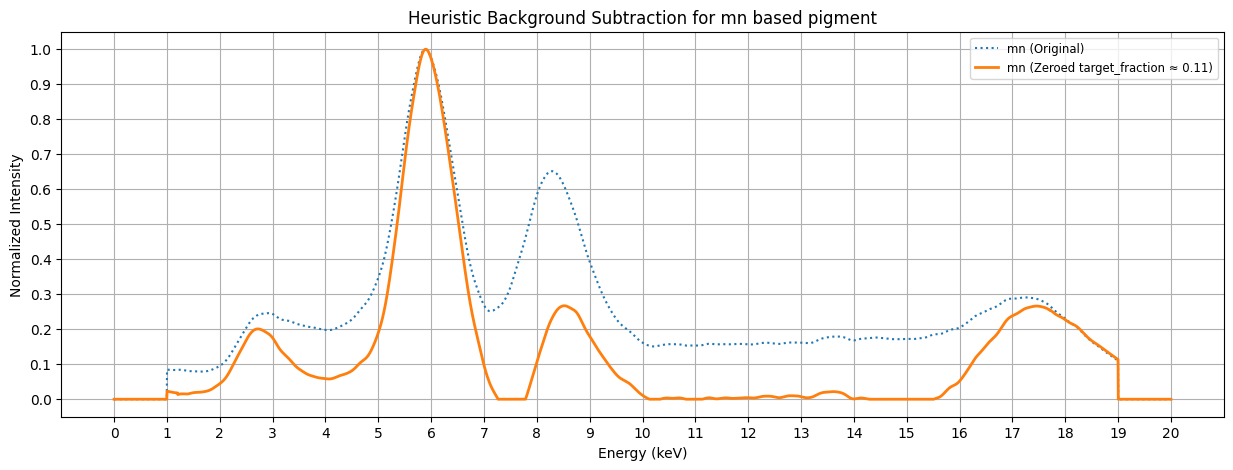

Processing: pb
  -> Selected result from target_fraction ≈ 0.11


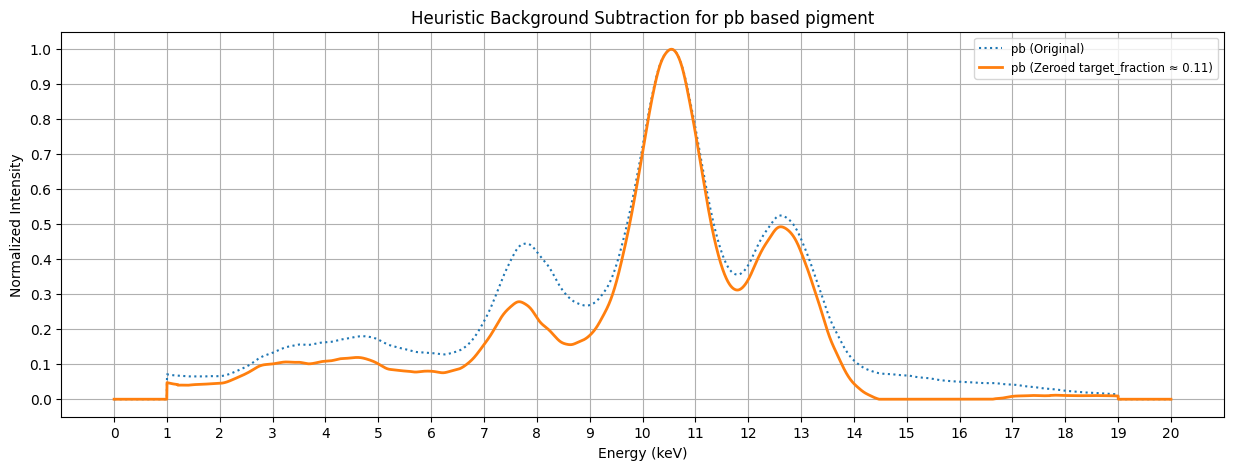

Processing: ti
  -> Selected result from target_fraction ≈ 0.11


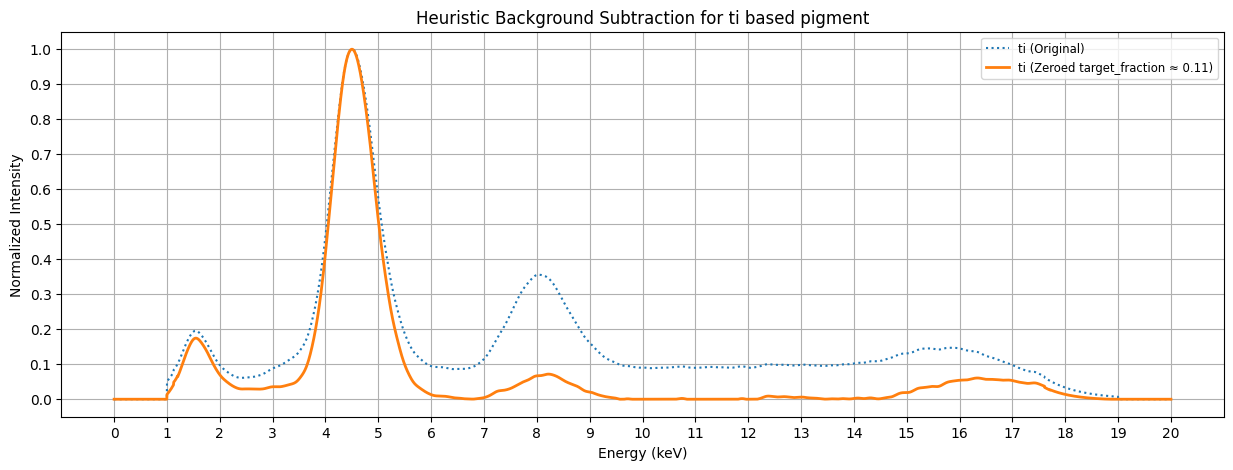

Processing: zn
  -> Selected result from target_fraction ≈ 0.11


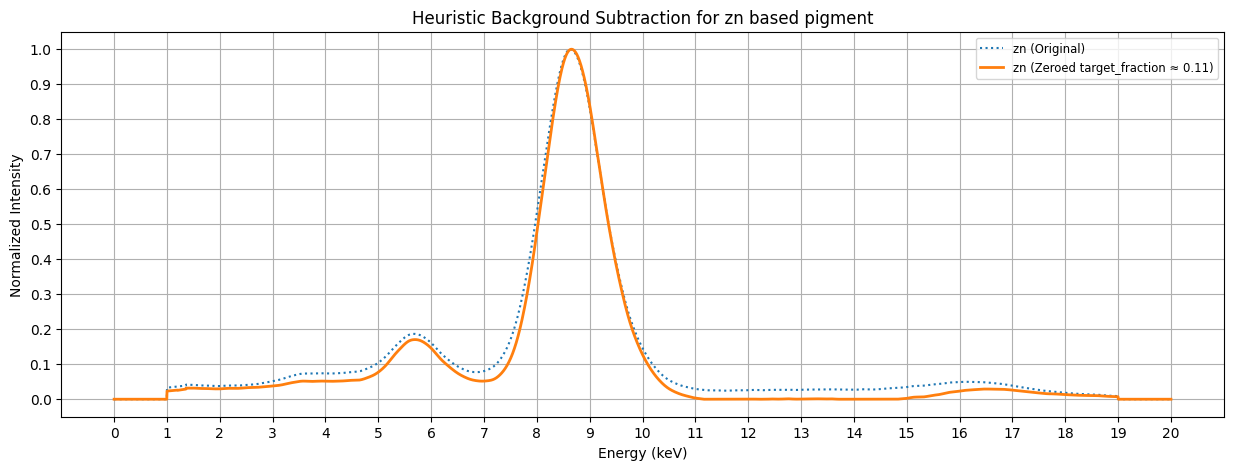

Processing: zr
  -> Selected result from target_fraction ≈ 0.11


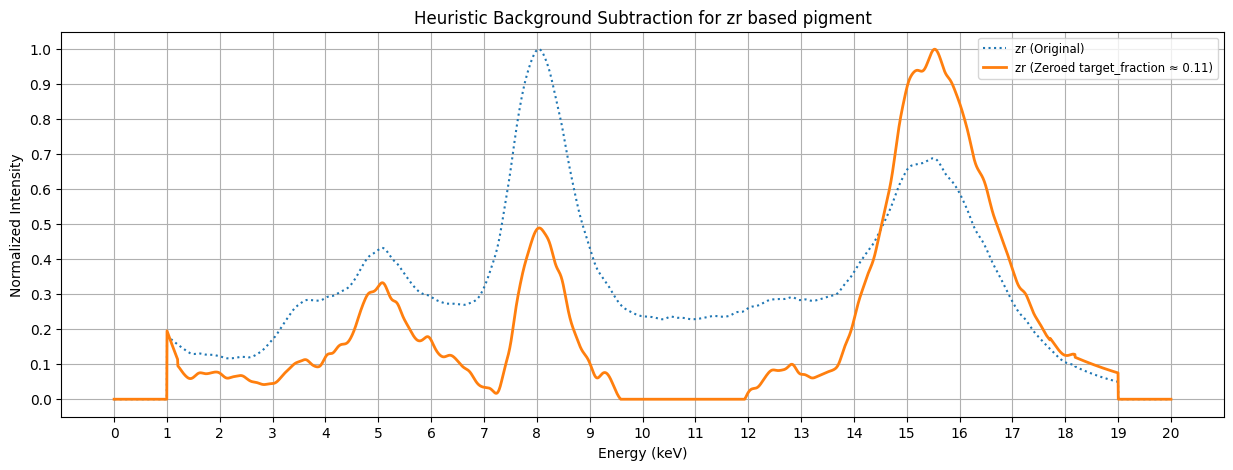


Saved 16 processed spectra.


In [11]:
import warnings 
from matplotlib import cm
from src.DataPreprocessor import DataPreprocessor
from random import randint



# ========================================================================
# Example Usage within your original loop structure
# ========================================================================

# Assume calibrated_spectra and energy_range are loaded
# Assume bisect_subtract_residual is defined

subtracted_residual_spectra = {}
tf_settings = {'tf_start': 0.1, 'tf_stop': 0.5, 'tf_step': 0.01} # Define settings once
energy_range = np.linspace(0, 20, list(calibrated_spectra.values())[0].shape[-1])

for name, spectrum in calibrated_spectra.items():
    if name == "wood": # Skip subtracting background from itself
         continue

    print(f"Processing: {name}")
    plt.figure(randint(2, 1000000), figsize=(15, 5)) # Unique figure for each pigment
    plt.plot(energy_range, spectrum / np.max(spectrum), label=f"{name} (Original)", linestyle=':') # Normalize original for comparison

    try:
        # Call the new function to get the best result and its TF
        # best_res, chosen_tf = DataPreprocessor.find_heuristic_subtraction(
        #     spectrum,
        #     calibrated_spectra["wood"],
        #     **tf_settings, # Pass the TF range settings
        #     # Add other bisect_subtract_residual args if needed, e.g.:
        #     # tol=0.01,
        #     # max_iter=100,
        #     verbose=True # Optional: see warnings for skipped TFs
        # )
        chosen_tf = 0.11
        best_res = DataPreprocessor.bisect_subtract_residual(
            spectrum,
            calibrated_spectra["wood"],
            chosen_tf,
            # tol=0.01,
            # max_iter=100,
            # verbose=True # Optional: see warnings for skipped TFs
        )

        if best_res is not None:
            subtracted_residual_spectra[name] = best_res
            label_text = f"{name} (Zeroed target_fraction ≈ {chosen_tf:.2f})" if chosen_tf is not None else f"{name} (Chosen Result)"
            plt.plot(energy_range, best_res, label=label_text, linewidth=2)
            print(f"  -> Selected result from target_fraction ≈ {chosen_tf:.2f}")
        else:
             print(f"  -> Failed to find a result for {name}")


    except (RuntimeError, ValueError) as e:
        print(f"  -> Failed to process {name}: {e}")
        # Optionally plot just the original if processing fails
        plt.plot(energy_range, spectrum / np.max(spectrum), label=f"{name} (Original Normalized - Failed Subtraction)", color='red')


    # --- Plotting customization ---
    plt.xticks(np.arange(0, 21, 1))
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.grid(True)
    plt.title(f"Heuristic Background Subtraction for {name} based pigment")
    plt.xlabel("Energy (keV)")
    plt.ylabel("Normalized Intensity")
    plt.legend(loc="upper right", fontsize="small")
    plt.ylim(-0.05, 1.05) # Slightly expanded ylim

    # Construct filename safely
    safe_name = name.replace(" ", "_").replace("/", "_") # Basic sanitization
    # Uncomment to save
    # plt.savefig(f"data/plots/spectra_subtracted_residual/{safe_name}_heuristic.svg", dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()


# --- Save the results ---
# Filter out potential None entries if processing failed for some items
final_spectra_to_save = {k: v for k, v in subtracted_residual_spectra.items() if v is not None}

if final_spectra_to_save:
     # Uncomment to save
    np.savez("data/objects/pigment_palette/2_subtracted_residual_spectra_heuristic.npz", **final_spectra_to_save)
    print(f"\nSaved {len(final_spectra_to_save)} processed spectra.")
else:
    print("\nNo spectra were successfully processed to save.")

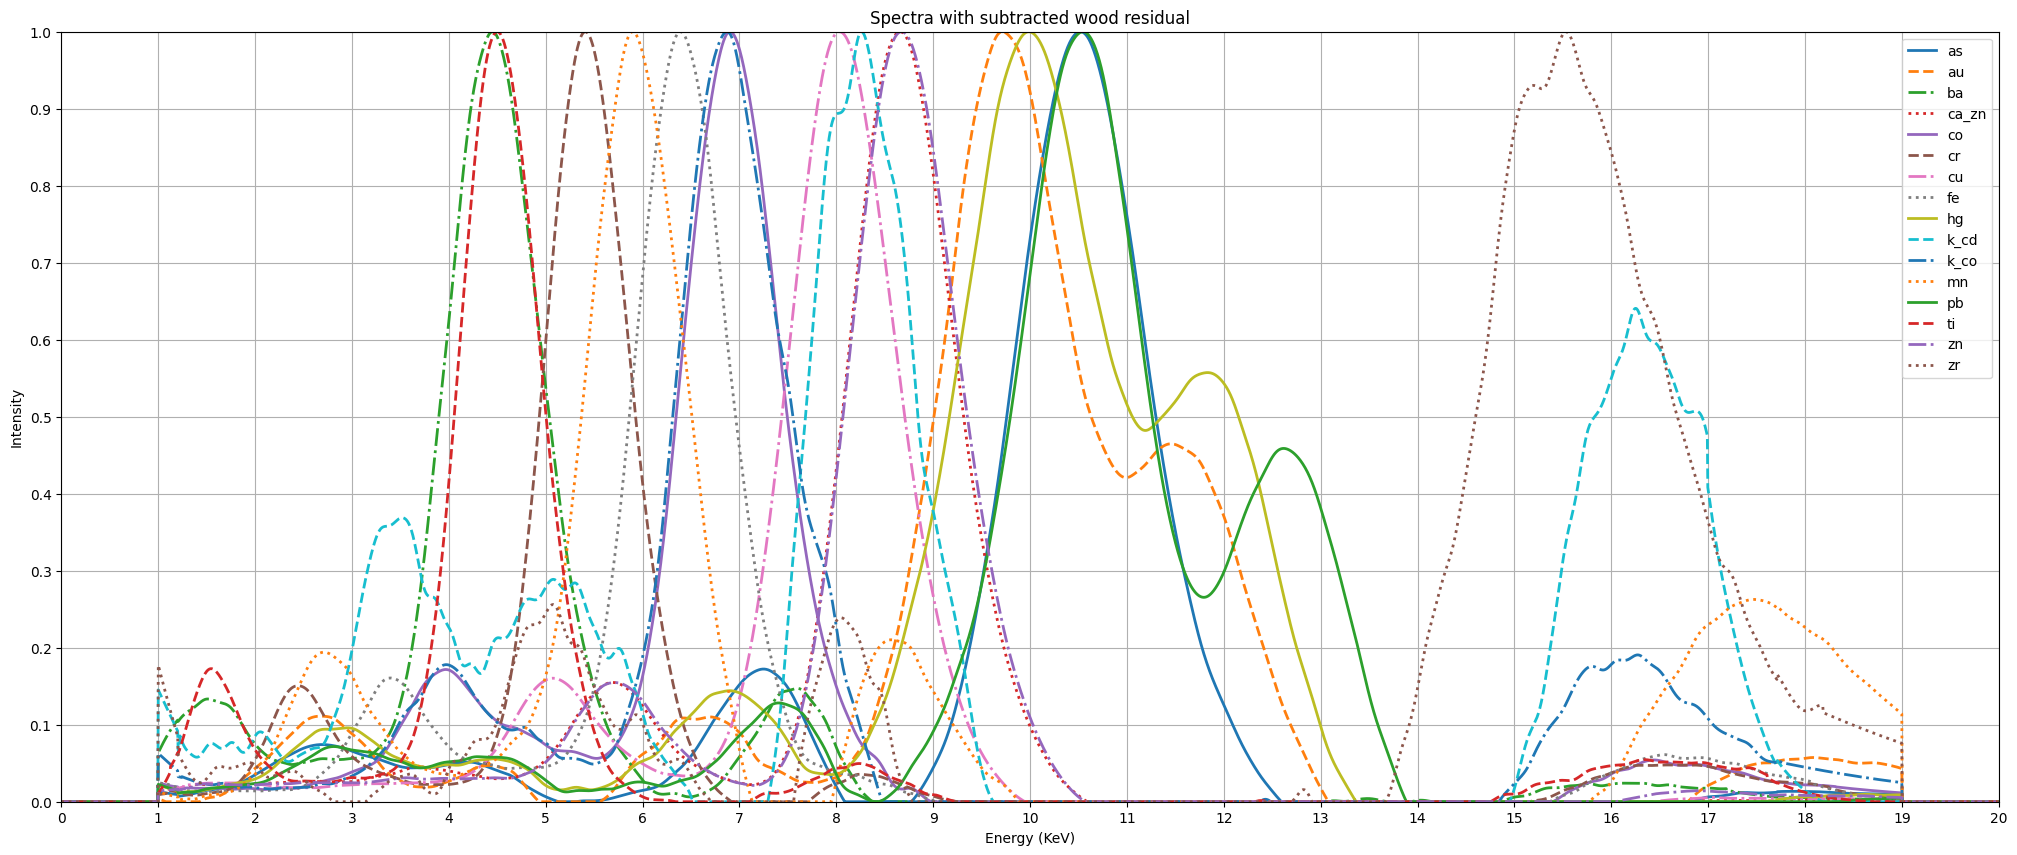

In [ ]:
line_styles = ['-', '--', '-.', ':']
plt.figure(figsize=(25, 10))
for (pad_name, spectrum), linestyle in zip(
    subtracted_residual_spectra.items(), itertools.cycle(line_styles)
):

    plt.plot(np.linspace(0, 20, 4096),spectrum, linestyle=linestyle, label=pad_name, linewidth=2)
    plt.set_cmap("tab10")

plt.legend()
plt.ylim(0, 1)
plt.xlim(0, 20)
plt.grid(True)
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel("Energy (KeV)")
plt.ylabel("Intensity")
plt.title("Spectra with subtracted wood residual")
plt.savefig("data/plots/subtracted_residual_spectra.svg", dpi=300, bbox_inches='tight',  pad_inches=0)
plt.show()